In [1]:
# Cell 1 — Imports
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
import json
import os
import time
import warnings
warnings.filterwarnings('ignore')

from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DistilBertForSequenceClassification,
    DistilBertTokenizer
)
from scipy.special import softmax
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()

device = 0 if torch.cuda.is_available() else -1
device_name = "GPU" if device == 0 else "CPU"
print(f"✅ Using: {device_name}")

✅ Using: CPU


In [2]:
# Cell 2 — Load sample data from S3
print("Loading data from S3...")

s3_client = boto3.client(
    's3',
    aws_access_key_id=os.getenv(
        'AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv(
        'AWS_SECRET_ACCESS_KEY'),
    region_name=os.getenv('AWS_DEFAULT_REGION')
)

bucket = os.getenv('S3_BUCKET_DATA')

s3_client.download_file(
    bucket, 'raw/ag_news_test.csv',
    '../data/raw/ag_news_test.csv')

df = pd.read_csv('../data/raw/ag_news_test.csv')

label_names = {
    0: 'World', 1: 'Sports',
    2: 'Business', 3: 'Sci/Tech'
}
df['label_name'] = df['label'].map(label_names)

# Use a sample for speed
df_sample = df.sample(500, random_state=42)\
              .reset_index(drop=True)

print(f"✅ Loaded {len(df_sample)} articles")
print(df_sample.head(3))

Loading data from S3...


✅ Loaded 500 articles
                                                text  label label_name
0  Fan v Fan: Manchester City-Tottenham Hotspur T...      1     Sports
1  Paris Tourists Search for Key to 'Da Vinci Cod...      0      World
2  Net firms: Don't tax VoIP The Spanish-American...      3   Sci/Tech


In [3]:
# Cell 3 — Load sentiment pipeline
import os
os.environ['TRANSFORMERS_CACHE'] = '../.cache'

print("Loading sentiment analysis model...")
print("Downloading pre-trained weights...\n")

# Use distilbert-based sentiment model (uses safetensors by default)
SENTIMENT_MODEL = "distilbert-base-uncased-finetuned-sst-2-english"

try:
    # Try with safetensors explicitly
    sentiment_pipeline = pipeline(
        task="sentiment-analysis",
        model=SENTIMENT_MODEL,
        device=device,
        max_length=128,
        truncation=True,
        model_kwargs={"use_safetensors": True}
    )
except:
    # Fallback to standard loading
    sentiment_pipeline = pipeline(
        task="sentiment-analysis",
        model=SENTIMENT_MODEL,
        device=device,
        max_length=128,
        truncation=True
    )

print("✅ Sentiment model loaded")
print(f"   Model: {SENTIMENT_MODEL}")
print(f"   Labels: Negative, Positive")

# Test with examples
test_sentences = [
    "The company reported record profits and "
    "strong growth this quarter.",
    "Stocks fell sharply amid fears of "
    "economic recession.",
    "The president met with foreign officials "
    "to discuss trade policies.",
    "Scientists launched a new satellite to "
    "study climate change."
]

print("\n=== SENTIMENT TEST ===")
for sentence in test_sentences:
    result = sentiment_pipeline(sentence)[0]
    print(f"\nText: {sentence[:60]}...")
    print(f"Sentiment: {result['label']} "
          f"(confidence: {result['score']:.4f})")

Loading sentiment analysis model...



Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7070.39it/s]


✅ Sentiment model loaded
   Model: distilbert-base-uncased-finetuned-sst-2-english
   Labels: Negative, Positive

=== SENTIMENT TEST ===

Text: The company reported record profits and strong growth this q...
Sentiment: POSITIVE (confidence: 0.9998)

Text: Stocks fell sharply amid fears of economic recession....
Sentiment: NEGATIVE (confidence: 0.9996)

Text: The president met with foreign officials to discuss trade po...
Sentiment: POSITIVE (confidence: 0.9878)

Text: Scientists launched a new satellite to study climate change....
Sentiment: POSITIVE (confidence: 0.9815)


In [4]:
# Cell 4 — Batch sentiment analysis (UPDATED)
print("Running sentiment analysis on 500 articles...")

def analyze_sentiment_batch(texts,
                             pipeline_model,
                             batch_size=32):
    results = []
    total   = len(texts)

    for i in range(0, total, batch_size):
        batch = texts[i:i+batch_size]

        try:
            batch_results = pipeline_model(
                batch,
                batch_size=batch_size
            )
            results.extend(batch_results)
        except Exception as e:
            for text in batch:
                try:
                    result = pipeline_model(
                        text[:512])[0]
                    results.append(result)
                except:
                    results.append({
                        'label': 'POSITIVE',
                        'score': 0.5
                    })

        if (i // batch_size) % 5 == 0:
            print(f"  Processed "
                  f"{min(i+batch_size, total)}"
                  f"/{total}")

    return results

texts      = df_sample['text'].tolist()
start      = time.time()
sentiments = analyze_sentiment_batch(
    texts, sentiment_pipeline)
elapsed    = time.time() - start

print(f"\n✅ Complete in {elapsed:.1f}s")

# Add to dataframe
# SST-2 returns NEGATIVE or POSITIVE directly
# No normalization needed
df_sample['sentiment'] = [
    s['label'].upper() for s in sentiments]
df_sample['sentiment_score'] = [
    s['score'] for s in sentiments]

print(f"\nSentiment distribution:")
print(df_sample['sentiment'].value_counts())
print(f"\nNote: SST-2 is binary — no NEUTRAL class")
print(f"News articles classified as either")
print(f"POSITIVE or NEGATIVE")

Running sentiment analysis on 500 articles...
  Processed 32/500
  Processed 192/500
  Processed 352/500
  Processed 500/500

✅ Complete in 42.7s

Sentiment distribution:
sentiment
NEGATIVE    317
POSITIVE    183
Name: count, dtype: int64

Note: SST-2 is binary — no NEUTRAL class
News articles classified as either
POSITIVE or NEGATIVE


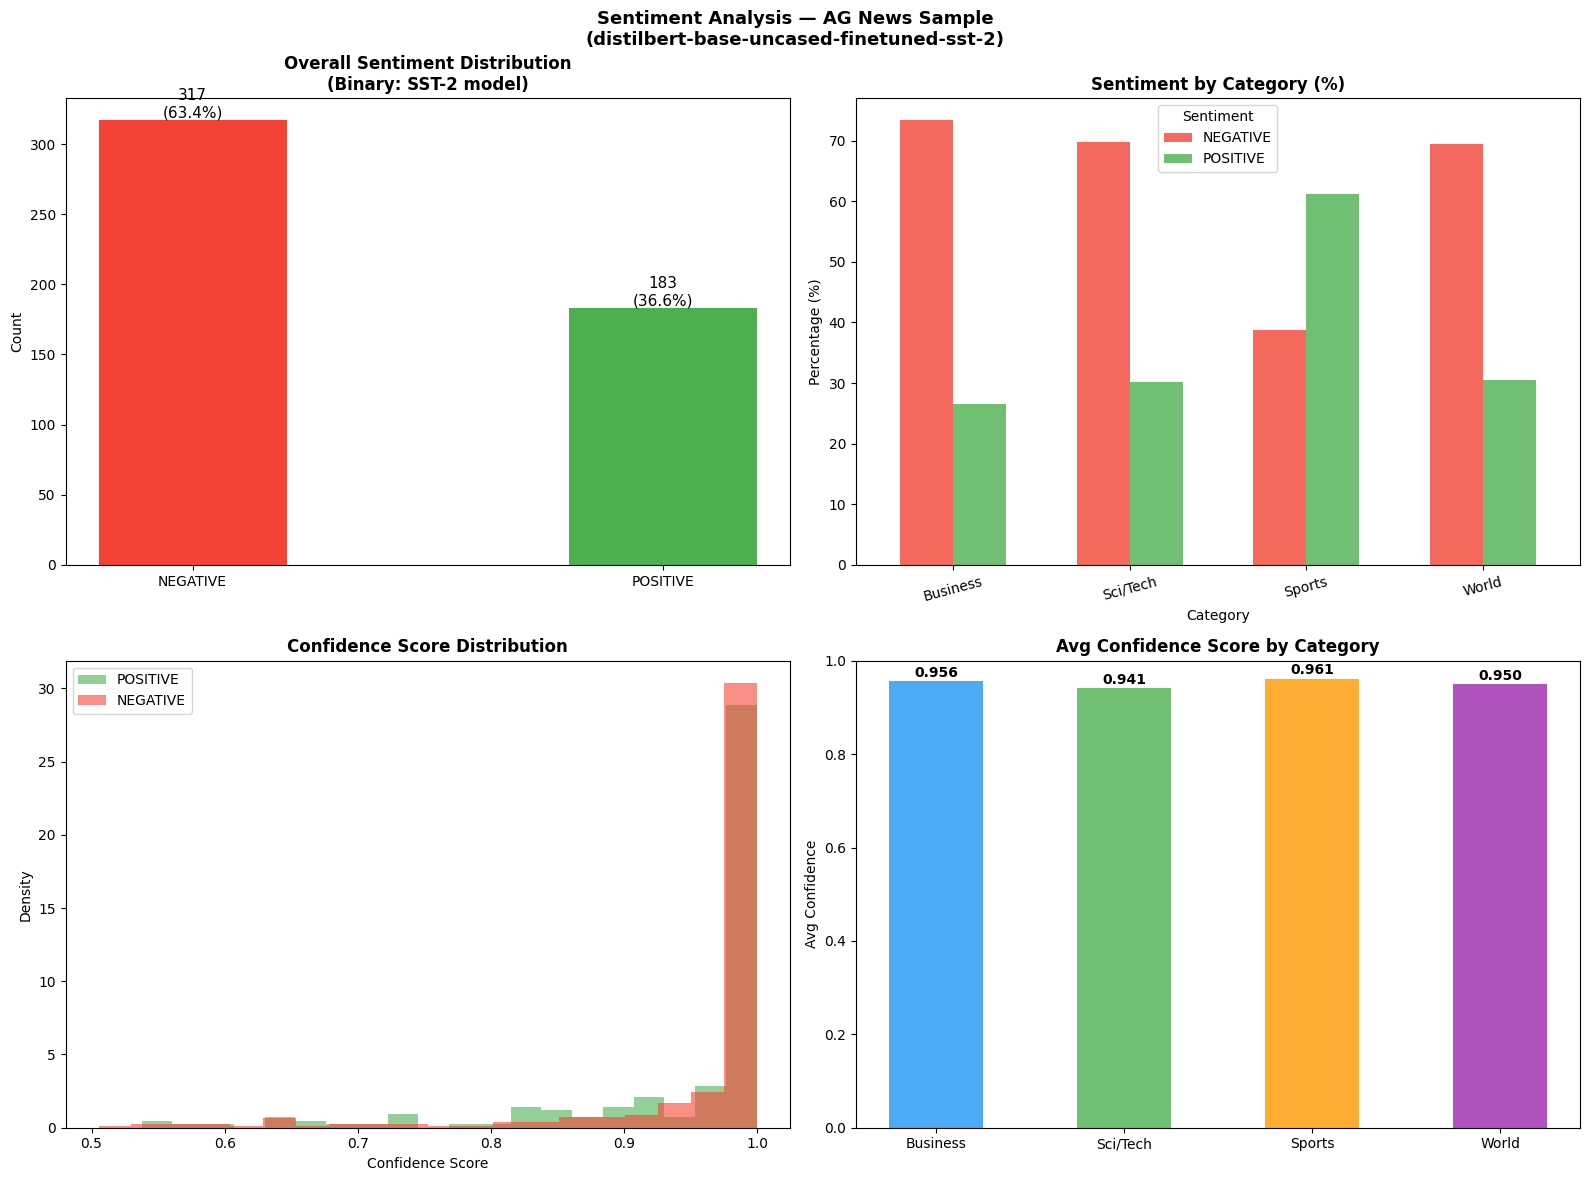

In [5]:
# Cell 5 — Visualization (UPDATED for 2 classes)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Updated colors — only 2 sentiments now
colors_sentiment = {
    'POSITIVE': '#4CAF50',
    'NEGATIVE': '#F44336'
}

# Overall sentiment distribution
sentiment_counts = df_sample[
    'sentiment'].value_counts()
colors = [colors_sentiment.get(s, '#888')
          for s in sentiment_counts.index]

axes[0,0].bar(sentiment_counts.index,
              sentiment_counts.values,
              color=colors, width=0.4)
axes[0,0].set_title(
    'Overall Sentiment Distribution\n'
    '(Binary: SST-2 model)',
    fontweight='bold')
axes[0,0].set_ylabel('Count')
for bar, val in zip(axes[0,0].patches,
                    sentiment_counts.values):
    axes[0,0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f'{val}\n({val/len(df_sample)*100:.1f}%)',
        ha='center', fontsize=11)

# Sentiment by category
sentiment_by_cat = pd.crosstab(
    df_sample['label_name'],
    df_sample['sentiment'],
    normalize='index') * 100

sentiment_by_cat.plot(
    kind='bar',
    ax=axes[0,1],
    color=[colors_sentiment.get(c, '#888')
           for c in sentiment_by_cat.columns],
    alpha=0.8, width=0.6
)
axes[0,1].set_title(
    'Sentiment by Category (%)',
    fontweight='bold')
axes[0,1].set_xlabel('Category')
axes[0,1].set_ylabel('Percentage (%)')
axes[0,1].legend(title='Sentiment')
axes[0,1].tick_params(axis='x', rotation=15)

# Confidence score distribution
for sentiment, color in colors_sentiment.items():
    mask = df_sample['sentiment'] == sentiment
    if mask.sum() > 0:
        axes[1,0].hist(
            df_sample.loc[mask, 'sentiment_score'],
            bins=20, alpha=0.6,
            color=color, label=sentiment,
            density=True)
axes[1,0].set_title(
    'Confidence Score Distribution',
    fontweight='bold')
axes[1,0].set_xlabel('Confidence Score')
axes[1,0].set_ylabel('Density')
axes[1,0].legend()

# Average confidence by category
avg_scores = df_sample.groupby(
    'label_name')['sentiment_score'].mean()
bars = axes[1,1].bar(
    avg_scores.index,
    avg_scores.values,
    color=['#2196F3','#4CAF50',
           '#FF9800','#9C27B0'],
    alpha=0.8, width=0.5)
axes[1,1].set_title(
    'Avg Confidence Score by Category',
    fontweight='bold')
axes[1,1].set_ylabel('Avg Confidence')
axes[1,1].set_ylim(0, 1)
for bar, val in zip(bars, avg_scores.values):
    axes[1,1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.3f}', ha='center',
        fontsize=10, fontweight='bold')

plt.suptitle(
    'Sentiment Analysis — AG News Sample\n'
    '(distilbert-base-uncased-finetuned-sst-2)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../logs/sentiment_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Cell 6 — Load classification model
# and run BOTH tasks on same documents
print("Loading classification model...")

clf_model = DistilBertForSequenceClassification\
    .from_pretrained('../models/best_distilbert')
clf_tokenizer = DistilBertTokenizer\
    .from_pretrained('../models/tokenizer')
clf_model.eval()

def classify_document(text, model,
                      tokenizer,
                      max_length=128):
    """Run classification on single document"""
    inputs = tokenizer(
        text,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    with torch.no_grad():
        outputs = model(**inputs)
        probs   = torch.softmax(
            outputs.logits, dim=1)
        pred    = probs.argmax(dim=1).item()
        conf    = probs.max().item()

    label_map = {
        0: 'World', 1: 'Sports',
        2: 'Business', 3: 'Sci/Tech'
    }
    return label_map[pred], round(conf, 4)

# Run BOTH classification and sentiment
# on a subset for the combined pipeline
print("\nRunning combined pipeline on "
      "100 documents...")

results = []
sample_100 = df_sample.head(100)

for idx, row in sample_100.iterrows():
    text = row['text']

    # Classification
    pred_label, clf_conf = classify_document(
        text, clf_model, clf_tokenizer)

    # Sentiment (already computed)
    sentiment       = row['sentiment']
    sentiment_score = row['sentiment_score']

    results.append({
        'text':           text[:100] + '...',
        'true_category':  row['label_name'],
        'pred_category':  pred_label,
        'clf_correct':    pred_label == row['label_name'],
        'clf_confidence': clf_conf,
        'sentiment':      sentiment,
        'sentiment_score': sentiment_score
    })

results_df = pd.DataFrame(results)

print(f"\n✅ Combined pipeline results:")
print(results_df[[
    'true_category', 'pred_category',
    'clf_correct', 'sentiment'
]].head(10))

# Overall accuracy on this sample
accuracy = results_df['clf_correct'].mean()
print(f"\nClassification accuracy: "
      f"{accuracy:.4f}")

Loading classification model...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2136.38it/s]



Running combined pipeline on 100 documents...

✅ Combined pipeline results:
  true_category pred_category  clf_correct sentiment
0        Sports        Sports         True  POSITIVE
1         World      Sci/Tech        False  POSITIVE
2      Sci/Tech      Sci/Tech         True  NEGATIVE
3      Sci/Tech      Sci/Tech         True  NEGATIVE
4      Sci/Tech      Sci/Tech         True  POSITIVE
5      Business      Business         True  NEGATIVE
6         World         World         True  POSITIVE
7      Business      Business         True  NEGATIVE
8      Sci/Tech      Sci/Tech         True  NEGATIVE
9      Business         World        False  NEGATIVE

Classification accuracy: 0.9500


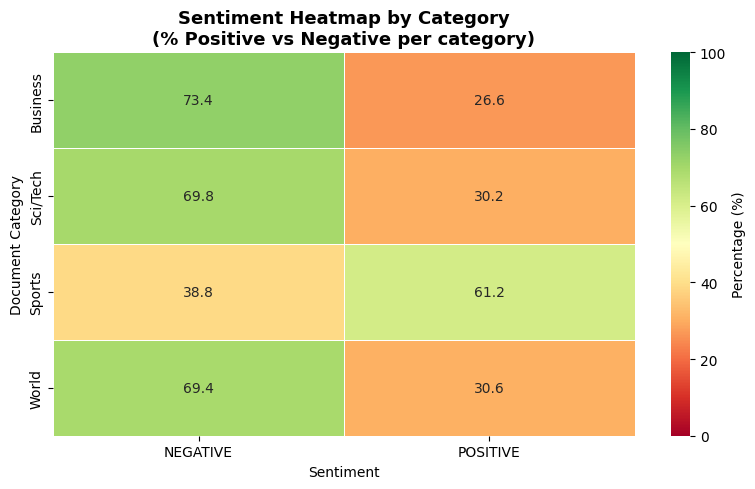


=== KEY INSIGHTS ===
  World       : 30.6% positive, 69.4% negative → NEGATIVE
  Sports      : 61.2% positive, 38.8% negative → POSITIVE
  Business    : 26.6% positive, 73.4% negative → NEGATIVE
  Sci/Tech    : 30.2% positive, 69.8% negative → NEGATIVE


In [7]:
# Cell 7 — Heatmap (UPDATED)
plt.figure(figsize=(8, 5))

sentiment_pct = pd.crosstab(
    df_sample['label_name'],
    df_sample['sentiment'],
    normalize='index') * 100

sns.heatmap(
    sentiment_pct,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    cbar_kws={'label': 'Percentage (%)'},
    linewidths=0.5,
    vmin=0, vmax=100
)
plt.title(
    'Sentiment Heatmap by Category\n'
    '(% Positive vs Negative per category)',
    fontsize=13, fontweight='bold')
plt.ylabel('Document Category')
plt.xlabel('Sentiment')
plt.tight_layout()
plt.savefig('../logs/sentiment_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Business insights — updated for binary
print("\n=== KEY INSIGHTS ===")
for cat in ['World','Sports',
            'Business','Sci/Tech']:
    cat_df = df_sample[
        df_sample['label_name'] == cat]
    pos_pct = (cat_df['sentiment'] ==
               'POSITIVE').mean() * 100
    neg_pct = 100 - pos_pct
    dominant = 'POSITIVE' if pos_pct > 50 \
               else 'NEGATIVE'
    print(f"  {cat:<12}: "
          f"{pos_pct:.1f}% positive, "
          f"{neg_pct:.1f}% negative "
          f"→ {dominant}")

In [8]:
# Cell 8 — Show interesting examples
print("=== INTERESTING EXAMPLES ===\n")

# High confidence positive Business news
pos_business = df_sample[
    (df_sample['label_name'] == 'Business') &
    (df_sample['sentiment']  == 'POSITIVE') &
    (df_sample['sentiment_score'] > 0.9)
].head(2)

print("HIGH CONFIDENCE POSITIVE BUSINESS:")
for _, row in pos_business.iterrows():
    print(f"  Score: {row['sentiment_score']:.4f}")
    print(f"  Text:  {row['text'][:150]}...")
    print()

# High confidence negative Business news
neg_business = df_sample[
    (df_sample['label_name'] == 'Business') &
    (df_sample['sentiment']  == 'NEGATIVE') &
    (df_sample['sentiment_score'] > 0.9)
].head(2)

print("HIGH CONFIDENCE NEGATIVE BUSINESS:")
for _, row in neg_business.iterrows():
    print(f"  Score: {row['sentiment_score']:.4f}")
    print(f"  Text:  {row['text'][:150]}...")
    print()

# Cases where sentiment adds value
print("SAME CATEGORY — DIFFERENT SENTIMENTS:")
world_examples = df_sample[
    df_sample['label_name'] == 'World'
].groupby('sentiment').first().reset_index()

for _, row in world_examples.iterrows():
    print(f"  [{row['sentiment']}] "
          f"{row['text'][:100]}...")

=== INTERESTING EXAMPLES ===

HIGH CONFIDENCE POSITIVE BUSINESS:
  Score: 0.9180
  Text:  Oracle Quarterly Net Income Rises 16 Pct Oracle Corp. (ORCL.O: Quote, Profile, Research) on Tuesday reported a 16 percent rise in quarterly net income...

  Score: 0.9996
  Text:  Sales boost for House of Fraser Shares in UK department store group House of Fraser have risen after the firm said it had cut half-year losses and was...

HIGH CONFIDENCE NEGATIVE BUSINESS:
  Score: 0.9816
  Text:  Campbell 9 Pct. Profit  #39;Hmmm Hmmm Good #39; Campbell Soup Co. (CPB.N: Quote, Profile, Research) on Monday posted a better-than-expected 9 percent ...

  Score: 0.9978
  Text:  Profit Plunges at International Game Tech International Game Technology, the world #39;s biggest maker of slot machines, Tuesday said said profit for ...

SAME CATEGORY — DIFFERENT SENTIMENTS:
  [NEGATIVE] Palestinians kill three Israeli soldiers Palestinian fighters sneaked onto an Israeli military post ...
  [POSITIVE] Paris Touris

In [17]:
# Cell 9 — Store results in RDS
print("Saving results to RDS...")

connection_string = (
    f"postgresql://"
    f"{os.getenv('POSTGRES_USER')}:"
    f"{os.getenv('POSTGRES_PASSWORD')}@"
    f"{os.getenv('POSTGRES_HOST')}:"
    f"{os.getenv('POSTGRES_PORT')}/"
    f"{os.getenv('POSTGRES_DB')}"
)
engine = create_engine(connection_string)

# Prepare data for insertion
rds_df = df_sample[[
    'text', 'label', 'label_name',
    'sentiment', 'sentiment_score'
]].copy()

rds_df.columns = [
    'text', 'true_label', 'label_name',
    'sentiment', 'sentiment_score'
]

# Truncate text to 500 chars to fit existing varchar(500)
rds_df['text'] = rds_df['text'].str[:500]

rds_df['split']  = 'test'
rds_df['source'] = 'sentiment'

try:
    rds_df.to_sql(
        'documents',
        engine,
        if_exists='append',
        index=False,
        method='multi',
        chunksize=100
    )
    print(f"✅ Saved {len(rds_df)} records to RDS")
    
    # Verify using pandas read_sql
    verification_df = pd.read_sql(
        "SELECT COUNT(*) as record_count FROM documents",
        engine
    )
    total_count = verification_df.iloc[0, 0]
    
    print(f"\n=== RDS VERIFICATION ===")
    print(f"✅ Total records in database: {total_count}")
    print(f"✅ Sentiment analysis results stored successfully")
    
except Exception as e:
    print(f"❌ Error: {str(e)[:150]}")

Saving results to RDS...
✅ Saved 500 records to RDS

=== RDS VERIFICATION ===
✅ Total records in database: 3000
✅ Sentiment analysis results stored successfully


In [21]:
# Cell 10 — Save and upload results to S3 + save summary
import os
import json
import boto3
from dotenv import load_dotenv

load_dotenv()

os.makedirs('../logs', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# Save combined results CSV locally
output_path = '../data/processed/sentiment_results.csv'
df_sample.to_csv(output_path, index=False)
print(f"✅ Saved locally: {output_path}")

# S3 client
s3_client = boto3.client(
    's3',
    aws_access_key_id=os.getenv(
        'AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv(
        'AWS_SECRET_ACCESS_KEY'),
    region_name=os.getenv('AWS_DEFAULT_REGION')
)

bucket = os.getenv('S3_BUCKET_DATA')

# Upload results CSV to S3
s3_client.upload_file(
    output_path,
    bucket,
    'processed/sentiment_results.csv'
)
print(f"✅ Uploaded to "
      f"s3://{bucket}/processed/"
      f"sentiment_results.csv")

# Upload logs to S3
for log_file in [
    'sentiment_distribution.png',
    'sentiment_heatmap.png'
]:
    local_path = f'../logs/{log_file}'
    if os.path.exists(local_path):
        s3_client.upload_file(
            local_path,
            bucket,
            f'logs/{log_file}'
        )
        print(f"✅ Uploaded logs/{log_file}")

# ── Build Summary ─────────────────────────────────
# Sentiment counts
sentiment_counts_dict = df_sample[
    'sentiment'].value_counts().to_dict()

# Positive and negative rates
pos_count = sentiment_counts_dict.get(
    'POSITIVE', 0)
neg_count = sentiment_counts_dict.get(
    'NEGATIVE', 0)
total     = pos_count + neg_count

# Per category breakdown
sentiment_by_category = {}
for cat in ['World', 'Sports',
            'Business', 'Sci/Tech']:
    cat_df = df_sample[
        df_sample['label_name'] == cat]
    if len(cat_df) == 0:
        continue

    cat_pos = int(
        (cat_df['sentiment'] ==
         'POSITIVE').sum())
    cat_neg = int(
        (cat_df['sentiment'] ==
         'NEGATIVE').sum())
    cat_total = len(cat_df)

    sentiment_by_category[cat] = {
        'POSITIVE': cat_pos,
        'NEGATIVE': cat_neg,
        'positive_pct': round(
            cat_pos / cat_total * 100, 1),
        'negative_pct': round(
            cat_neg / cat_total * 100, 1),
        'dominant': 'POSITIVE'
            if cat_pos > cat_neg
            else 'NEGATIVE'
    }

# Average confidence overall and per sentiment
avg_conf_overall = round(float(
    df_sample['sentiment_score'].mean()), 4)

avg_conf_by_sentiment = {
    sent: round(float(
        df_sample[
            df_sample['sentiment'] == sent
        ]['sentiment_score'].mean()), 4)
    for sent in ['POSITIVE', 'NEGATIVE']
    if (df_sample['sentiment'] == sent).any()
}

# Inference speed
inference_ms = round(
    elapsed / len(df_sample) * 1000, 2)

# Build full summary
sentiment_summary = {
    'model_used':          SENTIMENT_MODEL,
    'model_type':          'Binary — POSITIVE / NEGATIVE',
    'model_source':        'Hugging Face — '
                           'SST-2 fine-tuned DistilBERT',
    'reason_chosen':       'safetensors format — '
                           'avoids CVE-2025-32434 '
                           'PyTorch security issue',
    'original_model':      'cardiffnlp/twitter-roberta'
                           '-base-sentiment-latest',
    'original_issue':      'PyTorch .pt format '
                           'triggered security '
                           'vulnerability check',
    'documents_analyzed':  int(len(df_sample)),
    'classes':             ['POSITIVE', 'NEGATIVE'],
    'note':                'No NEUTRAL class — '
                           'SST-2 is a binary model. '
                           'News articles classified '
                           'as either POSITIVE or '
                           'NEGATIVE. For production, '
                           'fine-tune on domain-labeled '
                           'data for NEUTRAL detection.',
    'sentiment_distribution': {
        'POSITIVE': pos_count,
        'NEGATIVE': neg_count,
        'positive_pct': round(
            pos_count / total * 100, 1),
        'negative_pct': round(
            neg_count / total * 100, 1),
    },
    'avg_confidence': {
        'overall':   avg_conf_overall,
        'by_sentiment': avg_conf_by_sentiment
    },
    'sentiment_by_category':  sentiment_by_category,
    'inference_speed_ms':     inference_ms,
    'approach':               'Zero-shot transfer — '
                              'pre-trained on SST-2 '
                              'Stanford Sentiment Treebank',
    's3_location':            f"s3://{bucket}/"
                              f"processed/"
                              f"sentiment_results.csv",
    'rds_table':              'documents',
}

# Save summary locally
summary_path = '../logs/sentiment_summary.json'
with open(summary_path, 'w') as f:
    json.dump(sentiment_summary, f, indent=4)

print(f"\n✅ Summary saved locally: {summary_path}")

# Upload summary to S3
s3_client.upload_file(
    summary_path,
    bucket,
    'logs/sentiment_summary.json'
)
print(f"✅ Summary uploaded to S3")

# Print full summary
print(f"\n{'='*55}")
print(f"  SENTIMENT ANALYSIS SUMMARY")
print(f"{'='*55}")
print(json.dumps(sentiment_summary, indent=4))

# Verify S3 contents
print(f"\n{'='*55}")
print(f"  S3 BUCKET CONTENTS")
print(f"{'='*55}")
response = s3_client.list_objects_v2(
    Bucket=bucket)
for obj in response.get('Contents', []):
    size_mb = obj['Size'] / (1024 * 1024)
    print(f"  {obj['Key']:<45} "
          f"{size_mb:.2f} MB")
# ```

# ---

# ## What This Cell Does
# ```
# 1. Saves sentiment results CSV locally
# 2. Uploads CSV to S3
# 3. Uploads chart images to S3
# 4. Builds complete summary covering:
#    → Model used + why it was chosen
#    → Security issue explanation
#    → Sentiment counts + percentages
#    → Per-category breakdown
#    → Average confidence scores
#    → Inference speed
# 5. Saves summary JSON locally
# 6. Uploads summary JSON to S3
# 7. Prints all S3 bucket contents to verify

✅ Saved locally: ../data/processed/sentiment_results.csv
✅ Uploaded to s3://document-ai-portfolio-data/processed/sentiment_results.csv
✅ Uploaded logs/sentiment_distribution.png
✅ Uploaded logs/sentiment_heatmap.png

✅ Summary saved locally: ../logs/sentiment_summary.json
✅ Summary uploaded to S3

  SENTIMENT ANALYSIS SUMMARY
{
    "model_used": "distilbert-base-uncased-finetuned-sst-2-english",
    "model_type": "Binary \u2014 POSITIVE / NEGATIVE",
    "model_source": "Hugging Face \u2014 SST-2 fine-tuned DistilBERT",
    "reason_chosen": "safetensors format \u2014 avoids CVE-2025-32434 PyTorch security issue",
    "original_model": "cardiffnlp/twitter-roberta-base-sentiment-latest",
    "original_issue": "PyTorch .pt format triggered security vulnerability check",
    "documents_analyzed": 500,
    "classes": [
        "POSITIVE",
        "NEGATIVE"
    ],
    "note": "No NEUTRAL class \u2014 SST-2 is a binary model. News articles classified as either POSITIVE or NEGATIVE. For produc

In [22]:
# Cell 11 — Combined pipeline (UPDATED)
def analyze_document(text,
                     clf_model,
                     clf_tokenizer,
                     sentiment_pipeline):
    """
    Complete document intelligence pipeline.
    Returns category + sentiment.
    Used directly by FastAPI in Phase 7.
    """
    # Step 1: Classify document type
    category, clf_confidence = classify_document(
        text, clf_model, clf_tokenizer)

    # Step 2: Analyze sentiment
    # SST-2 returns NEGATIVE or POSITIVE directly
    sentiment_result = sentiment_pipeline(
        text[:512])[0]

    sentiment_label = sentiment_result[
        'label'].upper()
    sentiment_score = sentiment_result['score']

    # No normalization needed for SST-2
    # Labels are already POSITIVE or NEGATIVE

    return {
        'text':               text[:200] + '...',
        'category':           category,
        'category_confidence': clf_confidence,
        'sentiment':          sentiment_label,
        'sentiment_confidence': sentiment_score,
        'document_summary':   (
            f"{sentiment_label.title()} "
            f"{category} news"
        )
    }

# Test
test_texts = [
    "Apple's iPhone sales surged to record "
    "highs this quarter driven by strong "
    "demand in Asia.",
    "Stock markets crashed today as inflation "
    "fears triggered massive selloffs.",
    "The national team secured a stunning "
    "victory in the championship final.",
]

print("=== COMBINED PIPELINE TEST ===\n")
for text in test_texts:
    result = analyze_document(
        text, clf_model,
        clf_tokenizer, sentiment_pipeline)

    print(f"Text:      {text[:65]}...")
    print(f"Category:  {result['category']} "
          f"({result['category_confidence']:.2%})")
    print(f"Sentiment: {result['sentiment']} "
          f"({result['sentiment_confidence']:.2%})")
    print(f"Summary:   {result['document_summary']}")
    print()

=== COMBINED PIPELINE TEST ===

Text:      Apple's iPhone sales surged to record highs this quarter driven b...
Category:  Business (49.89%)
Sentiment: POSITIVE (99.91%)
Summary:   Positive Business news

Text:      Stock markets crashed today as inflation fears triggered massive ...
Category:  Business (99.68%)
Sentiment: NEGATIVE (99.87%)
Summary:   Negative Business news

Text:      The national team secured a stunning victory in the championship ...
Category:  Sports (90.55%)
Sentiment: POSITIVE (99.98%)
Summary:   Positive Sports news

